Group Pipeline — Diabetes and LifeStyle Dataset
IT2011 — Artificial Intelligence and Machine Learning — Progress Review I


Dataset: Diabetes and LifeStyle Dataset (97,297 rows x 31 columns)
Group task: integrate each member's individual preprocessing technique into a single,
logically-ordered pipeline, and produce the cleaned/engineered dataset used for modeling.

Each stage below re-runs that member's core logic against the previous stage's output, so the
full pipeline can be executed top-to-bottom in one run and produces the same
stage_.csv checkpoint files saved in results/outputs/.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek


In [2]:
RAW_PATH = 'data/raw/Diabetes_and_LifeStyle_Dataset_.csv'
df = pd.read_csv(RAW_PATH)
print("Raw shape:", df.shape)
df.head()

Raw shape: (97297, 31)


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


Stage 1 — Missing Data (Rashmika)

In [3]:
print("Explicit NaNs:", df.isnull().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())

Explicit NaNs: 0
Exact duplicate rows: 0


In [4]:
clinical_cols = ['bmi', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
                  'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level',
                  'hba1c', 'systolic_bp', 'diastolic_bp', 'waist_to_hip_ratio']
implausible = sum((df[c] <= 0).sum() for c in clinical_cols)
print("Implausible (<=0) clinical readings:", implausible)

Implausible (<=0) clinical readings: 0


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after Stage 1:", df.shape)

Shape after Stage 1: (97297, 31)


Stage 2 — Encoding Categorical Variables (hiruni kawya)

In [6]:
education_order = {'No formal': 0, 'Highschool': 1, 'Graduate': 2, 'Postgraduate': 3}
income_order = {'Low': 0, 'Lower-Middle': 1, 'Middle': 2, 'Upper-Middle': 3, 'High': 4}
smoking_order = {'Never': 0, 'Former': 1, 'Current': 2}
diabetes_stage_order = {'No Diabetes': 0, 'Pre-Diabetes': 1, 'Gestational': 2, 'Type 2': 3, 'Type 1': 4}

df['education_level'] = df['education_level'].map(education_order)
df['income_level'] = df['income_level'].map(income_order)
df['smoking_status'] = df['smoking_status'].map(smoking_order)
df['diabetes_stage_encoded'] = df['diabetes_stage'].map(diabetes_stage_order)

nominal_cols = ['gender', 'ethnicity', 'employment_status']
df = pd.get_dummies(df, columns=nominal_cols, prefix=nominal_cols, drop_first=False)

print("Shape after Stage 2:", df.shape)
assert df.isnull().sum().sum() == 0, "Encoding introduced unexpected NaNs"
df.head(3)

Shape after Stage 2: (97297, 41)


,Age,education_level,income_level,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,...,gender_Other,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,58,1,1,0,0,215,5.7,7.9,7.9,0,...,False,True,False,False,False,False,True,False,False,False
1,52,1,2,1,1,143,6.7,6.5,8.7,0,...,False,False,False,False,False,True,True,False,False,False
2,60,1,2,0,1,57,6.4,10.0,8.1,1,...,False,False,False,True,False,False,False,False,False,True


Stage 3 — Outlier Treatment (laksith)

In [7]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

numeric_check_cols = ['bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
                       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
                       'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c',
                       'alcohol_consumption_per_week', 'physical_activity_minutes_per_week']

for col in numeric_check_cols:
    low, high = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=low, upper=high)

print("Shape after Stage 3 (capping, no rows dropped):", df.shape)

Shape after Stage 3 (capping, no rows dropped): (97297, 41)


Stage 4 — Normalization / Scaling (faij ahamed)

In [8]:
leakage = ['diagnosed_diabetes', 'diabetes_risk_score']
scale_exclude = leakage + ['diabetes_stage_encoded']
for_loop= df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in for_loop if c not in scale_exclude]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(f"Scaled {len(numeric_cols)} numeric feature columns with StandardScaler")
df[numeric_cols].describe().T[['mean', 'std']].head()

Scaled 25 numeric feature columns with StandardScaler


,mean,std
Age,1.840311e-16,1.000005
education_level,-7.667964e-17,1.000005
income_level,-5.710807e-17,1.000005
smoking_status,7.127555e-17,1.000005
alcohol_consumption_per_week,-6.952287e-17,1.000005


Stage 5 — Feature Engineering & Selection (dharshika)

In [9]:
df = df.drop(
    columns=[c for c in leakage + ['diabetes_stage'] if c in df.columns]
)

corr = df.corr(numeric_only=True)
target_corr = corr['diabetes_stage_encoded'].drop('diabetes_stage_encoded')
weak_cols = target_corr[abs(target_corr) < 0.02].index.tolist()
df = df.drop(columns=weak_cols)

print(f"Dropped {len(weak_cols)} weakly-correlated columns")

Dropped 18 weakly-correlated columns


In [10]:
print("Final feature-engineered shape:", df.shape)
df.to_csv('results/outputs/final_processed_dataset.csv', index=False)

Final feature-engineered shape: (97297, 20)


Stage 6 — Class Imbalance Handling (Uditha Banuka)

The target is severely imbalanced across all 5 classes (`Type 2` ~60%, `Pre-Diabetes` ~32%,
`No Diabetes` ~8%, `Gestational` ~0.3%, `Type 1` ~0.1%). Plain SMOTE oversampling every
minority up to the majority count would require ~495x synthetic growth for `Type 1`'s 94
rows, which mostly repeats a handful of directions in feature space rather than adding real
signal. Instead: `Type 1` is dropped (documented trade-off, too few real examples to
resample reliably), and the remaining 4 classes are balanced with a **hybrid** technique —
random under-sampling of the majority (`Type 2`), SMOTE oversampling of the minorities
(`No Diabetes`, `Gestational`) up to a moderate target, and Tomek-link cleaning of the
resulting boundary — fit only on the training split (see Member 6's notebook for the full
before/after analysis).

In [11]:
X = df.drop(columns=['diabetes_stage_encoded'])
y = df['diabetes_stage_encoded']

# Drop Type 1 (class 4) — too few real rows to resample reliably
keep_mask = y != 4
X, y = X[keep_mask], y[keep_mask]
print(f"Dropped 'Type 1' rows. Remaining shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nClass distribution before balancing (training split only):")
print(y_train.value_counts().sort_index())

target_n = int(y_train.value_counts().loc[1])  # size of 2nd-largest class (Pre-Diabetes)

# 1) trim the majority class down to the target
under = RandomUnderSampler(sampling_strategy={3: target_n}, random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)

# 2) SMOTE the minority classes up to the target, then clean overlapping Tomek-link pairs
smote_tomek = SMOTETomek(sampling_strategy={0: target_n, 2: target_n}, random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_under, y_under)

print("\nClass distribution after under-sampling + SMOTE + Tomek cleaning:")
print(y_train_res.value_counts().sort_index())
print("\nTest set left untouched:", X_test.shape)

Dropped 'Type 1' rows. Remaining shape: (97180, 19)

Class distribution before balancing (training split only):
diabetes_stage_encoded
0     6190
1    24810
2      214
3    46530
Name: count, dtype: int64

Class distribution after under-sampling + SMOTE + Tomek cleaning:
diabetes_stage_encoded
0    24797
1    23006
2    24810
3    23015
Name: count, dtype: int64

Test set left untouched: (19436, 19)


---
## Group EDA Summary — Combined Visualization

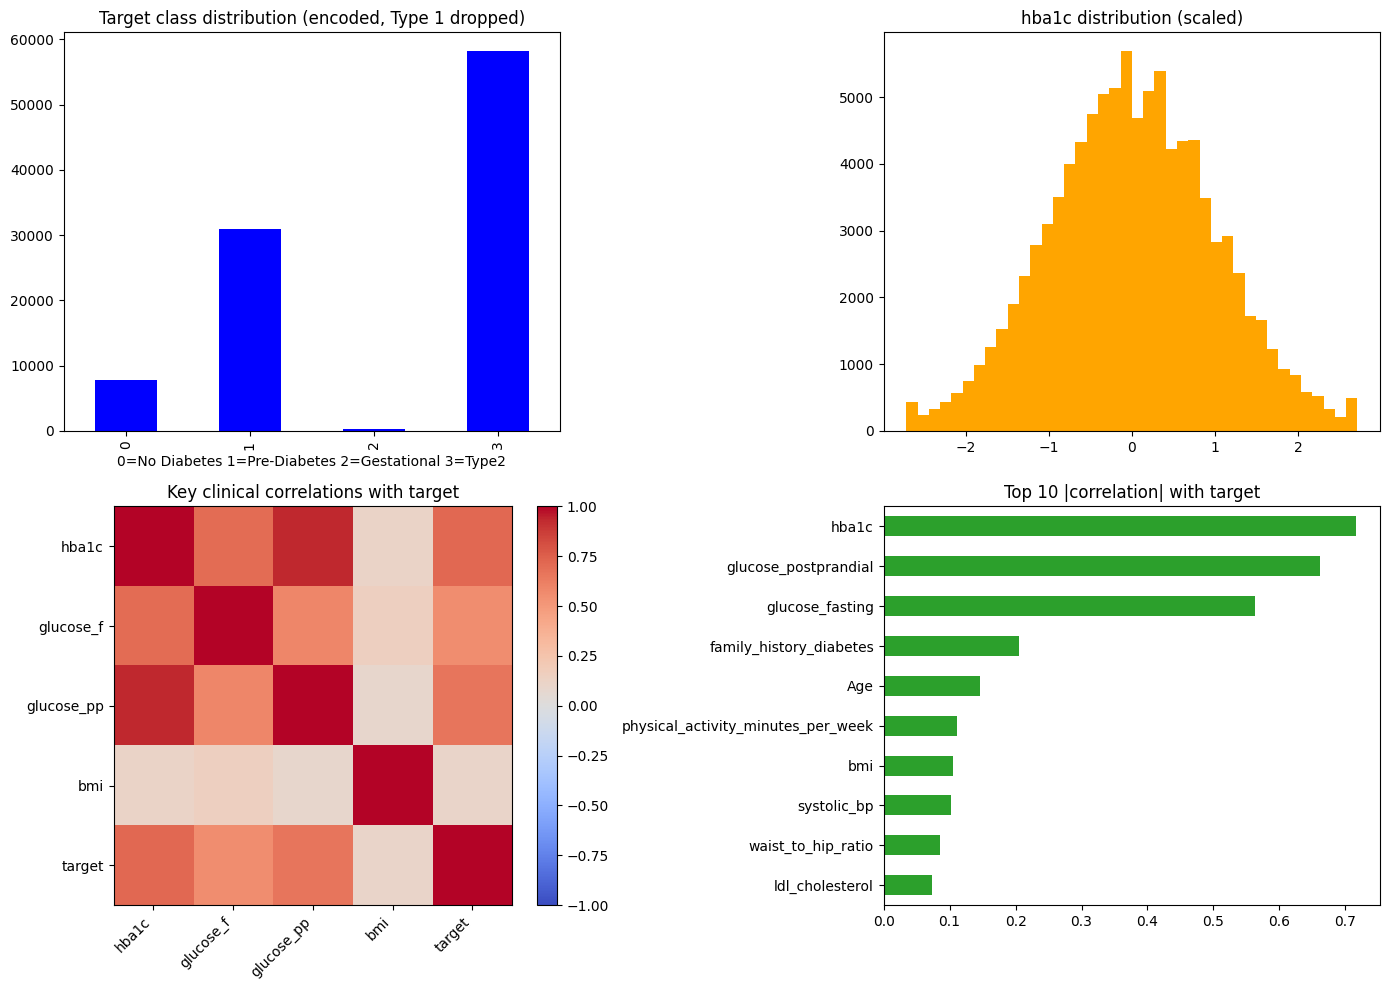

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

y.value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='blue')
axes[0,0].set_title('Target class distribution (encoded, Type 1 dropped)')
axes[0,0].set_xlabel('0=No Diabetes 1=Pre-Diabetes 2=Gestational 3=Type2')

axes[0,1].hist(df['hba1c'], bins=40, color='orange')
axes[0,1].set_title('hba1c distribution (scaled)')

im = axes[1,0].imshow(corr.loc[['hba1c','glucose_fasting','glucose_postprandial','bmi',
                                  'diabetes_stage_encoded'],
                                 ['hba1c','glucose_fasting','glucose_postprandial','bmi',
                                  'diabetes_stage_encoded']], cmap='coolwarm', vmin=-1, vmax=1)
axes[1,0].set_xticks(range(5)); axes[1,0].set_xticklabels(
    ['hba1c','glucose_f','glucose_pp','bmi','target'], rotation=45, ha='right')
axes[1,0].set_yticks(range(5)); axes[1,0].set_yticklabels(
    ['hba1c','glucose_f','glucose_pp','bmi','target'])
axes[1,0].set_title('Key clinical correlations with target')
plt.colorbar(im, ax=axes[1,0], fraction=0.046)

target_corr.abs().sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[1,1], color='#2ca02c')
axes[1,1].set_title('Top 10 |correlation| with target')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('results/eda_visualizations/group_summary_dashboard.png', dpi=120)
plt.show()

In [13]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_res, y_train_res)

y_pred = knn.predict(X_test)
print("Test accuracy:", knn.score(X_test, y_test))
print()
print(classification_report(y_test, y_pred, target_names=[
    'No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 2']))

Test accuracy: 0.7025108046923235

              precision    recall  f1-score   support

 No Diabetes       0.47      0.90      0.62      1547
Pre-Diabetes       0.65      0.67      0.66      6203
 Gestational       0.00      0.13      0.01        53
      Type 2       0.94      0.70      0.80     11633

    accuracy                           0.70     19436
   macro avg       0.52      0.60      0.52     19436
weighted avg       0.81      0.70      0.74     19436



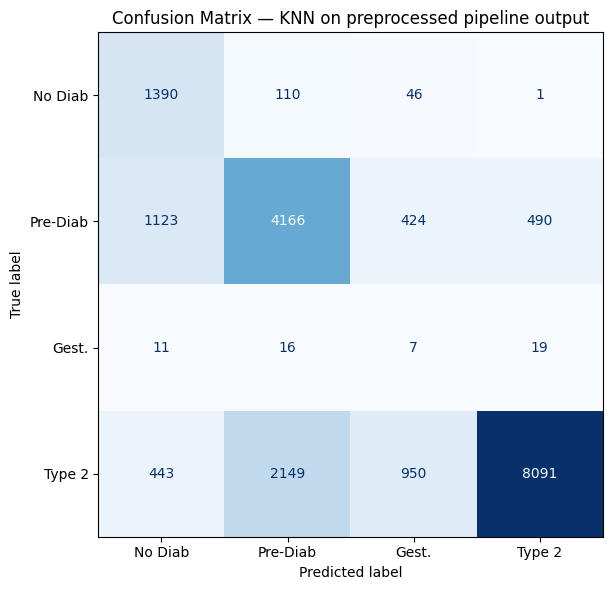

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Diab','Pre-Diab','Gest.','Type 2'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — KNN on preprocessed pipeline output')
plt.tight_layout()
plt.savefig('results/eda_visualizations/confusion_matrix.png', dpi=120)
plt.show()

Group Conclusion
The six individual preprocessing stages integrate cleanly into a single, reproducible
pipeline:

Missing data — verified 0 NaNs, 0 duplicates, 0 implausible readings; a
   tested imputer is available for future data.
Encoding — ordinal mapping for ordered categories, one-hot for nominal ones,
   zero information loss.
Outlier treatment — IQR-based capping preserved all records while taming
   extreme leverage points, avoiding loss of minority diabetic classes.
Scaling — StandardScaler applied so no feature dominates KNN's distance
   metric.
Feature engineering — removed 2 leakage columns and weakly-correlated
   columns, added an engineered pulse_pressure feature.
Class balancing — `Type 1` dropped (too rare to resample reliably); the
   remaining 4 classes balanced on the training split only via random
   under-sampling of the majority + SMOTE oversampling of the minorities +
   Tomek-link cleaning, instead of plain SMOTE-to-majority.

The resulting dataset (results/outputs/final_processed_dataset.csv) plus the balanced
training split are fed into a baseline KNN classifier, evaluated on the untouched,
still-imbalanced 4-class test split.